1. Ek naya chhota synthetic dataset khud banao (jaisa Day 20 mein employees wala banaya tha):

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(7)
n = 200

students = pd.DataFrame({
    'student_id': range(1, n+1),
    'study_hours': np.random.normal(5, 2, n).clip(0.5, 12),
    'attendance_pct': np.random.normal(75, 15, n).clip(30, 100),
    'score': np.random.normal(60, 20, n).clip(0, 100),
    'department': np.random.choice(['CS', 'ECE', 'Mech', 'Civil'], n),
    'passed': np.random.choice([0, 1], n, p=[0.3, 0.7])
})
print(students.head())

   student_id  study_hours  attendance_pct      score department  passed
0           1     8.381051       49.749047  58.799971      Civil       0
1           2     4.068125       90.225224  75.753707        ECE       1
2           3     5.065640       53.376844  31.365918        ECE       1
3           4     5.815033       54.845572  68.678189        ECE       1
4           5     3.422154       69.574975  62.778201      Civil       1


1. score column ka mean, median, std, aur skewness nikaalo — kya distribution normal ke close hai?

In [3]:
score_mean = students['score'].mean()
score_median = students['score'].median()
score_std = students['score'].std()
score_skew = students['score'].skew()

print(f"Mean: {score_mean:.2f}")
print(f"Median: {score_median:.2f}")
print(f"Standard Deviation: {score_std:.2f}")
print(f"Skewness: {score_skew:.2f}")

Mean: 58.78
Median: 58.32
Standard Deviation: 19.11
Skewness: -0.19


- Kya distribution normal ke close hai? Kyunki skewness 0 ke kafi kareeb hai aur mean-median lagbhag barabar hain, distribution normal distribution ke kafi close hai (clipped values ki wajah se slight boundary effects ho sakte hain).

2. study_hours aur score ka Pearson correlation nikaalo, p-value ke saath.

In [5]:
corr, p_val = stats.pearsonr(students['study_hours'], students['score'])
print(f"Pearson Correlation: {corr:.3f}")
print(f"p-value: {p_val:.5f}")

Pearson Correlation: 0.048
p-value: 0.49856


3. H0/H1 likho aur t-test chalao: kya passed=1 aur passed=0 groups ka study_hours significantly alag hai?

- H0 (Null Hypothesis): passed=1 aur passed=0 groups ke mean study_hours mein koi significant difference nahi hai.
- H1 (Alternative Hypothesis): Dono groups ke mean study_hours mein significant difference hai.

In [6]:
group0 = students[students['passed'] == 0]['study_hours']
group1 = students[students['passed'] == 1]['study_hours']

t_stat, p_val_t = stats.ttest_ind(group0, group1)
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val_t:.5f}")

t-statistic: -1.475
p-value: 0.14174


4. department aur passed ke beech chi-square test chalao — koi association hai kya?

In [7]:
contingency_table = pd.crosstab(students['department'], students['passed'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi2 statistic: {chi2:.3f}")
print(f"p-value: {p_chi2:.5f}")

Chi2 statistic: 3.333
p-value: 0.34301


5. score column mein IQR method se outliers dhoondo.

In [8]:
Q1 = students['score'].quantile(0.25)
Q3 = students['score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = students[(students['score'] < lower_bound) | (students['score'] > upper_bound)]
print(f"Number of outliers found in score: {len(outliers)}")

Number of outliers found in score: 3


6. Ek line plot banao — student_id ke order mein score ka 10-point moving average (rolling(10).mean() use karo).

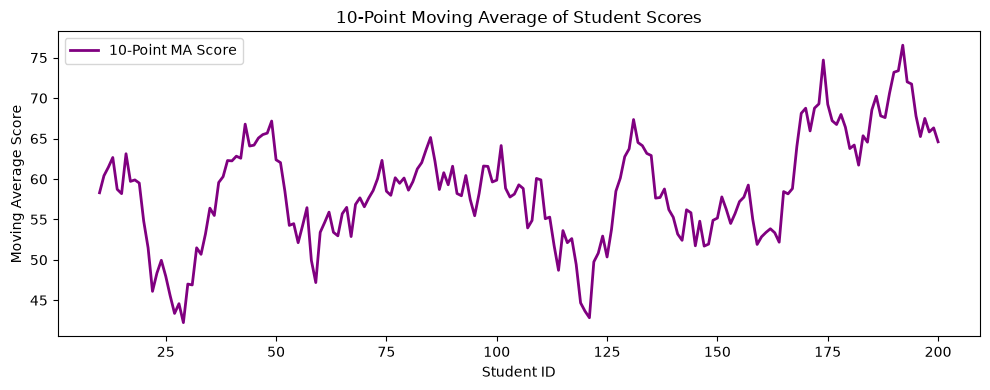

In [9]:
students['score_ma10'] = students['score'].rolling(window=10).mean()

plt.figure(figsize=(10, 4))
plt.plot(students['student_id'], students['score_ma10'], label='10-Point MA Score', color='purple', linewidth=2)
plt.xlabel('Student ID')
plt.ylabel('Moving Average Score')
plt.title('10-Point Moving Average of Student Scores')
plt.legend()
plt.tight_layout()
plt.show()

7. Ek bar chart banao — department-wise average score.

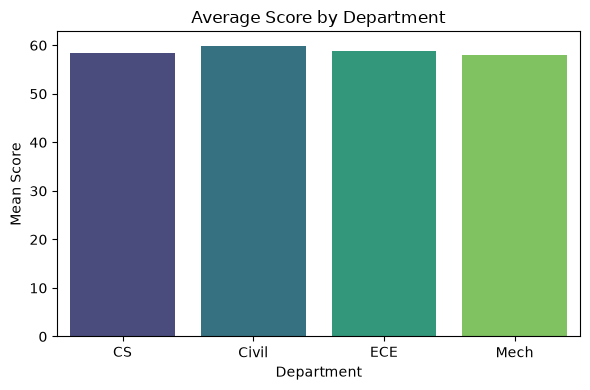

In [10]:
dept_score = students.groupby('department')['score'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=dept_score, x='department', y='score', palette='viridis', hue='department', legend=False)
plt.title('Average Score by Department')
plt.ylabel('Mean Score')
plt.xlabel('Department')
plt.tight_layout()
plt.show()

8. Ek histogram banao attendance_pct ka, 3 alag bins values ke saath subplot mein.

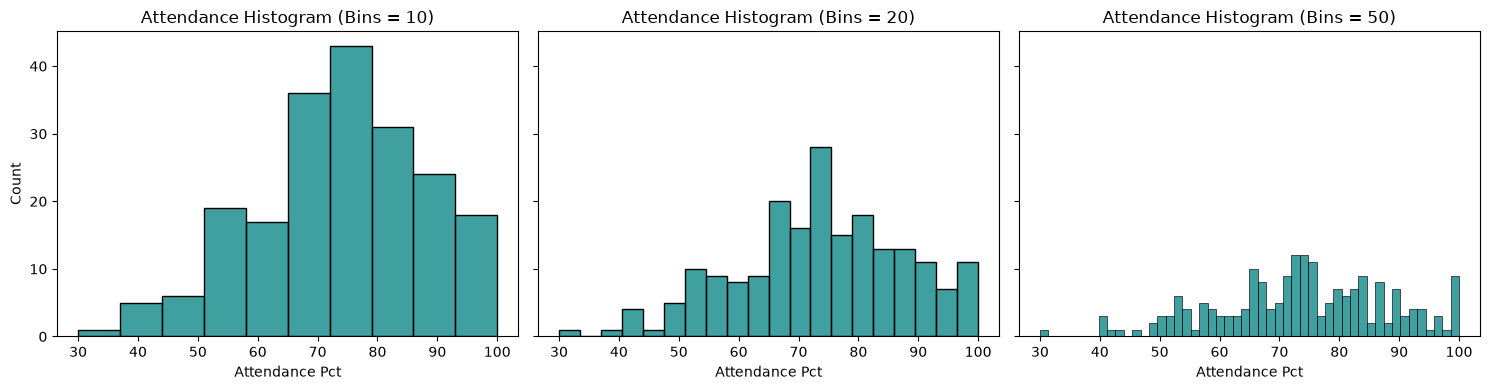

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bins_list = [10, 20, 50]

for i, b in enumerate(bins_list):
    sns.histplot(students['attendance_pct'], bins=b, ax=axes[i], color='teal', edgecolor='black')
    axes[i].set_title(f'Attendance Histogram (Bins = {b})')
    axes[i].set_xlabel('Attendance Pct')

plt.tight_layout()
plt.show()

9. Ek scatter plot banao study_hours vs score, hue='passed' ke saath, regression line sahit.

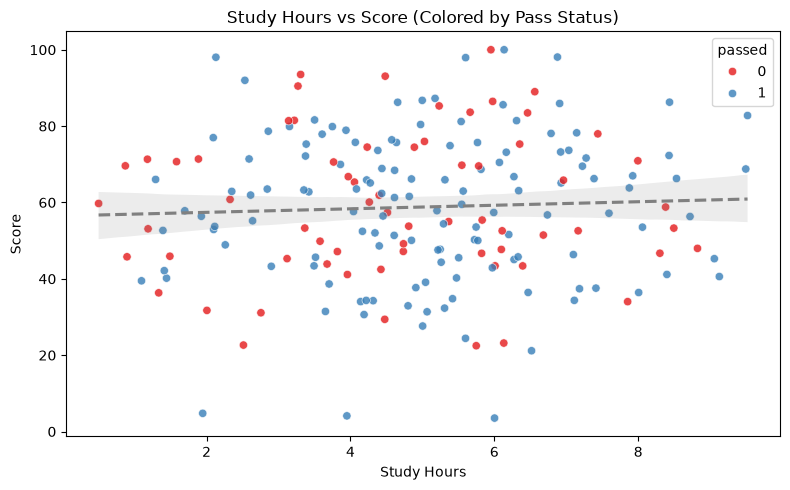

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=students, x='study_hours', y='score', hue='passed', palette='Set1', alpha=0.8)
sns.regplot(data=students, x='study_hours', y='score', scatter=False, color='gray', line_kws={'linestyle': '--'})
plt.title('Study Hours vs Score (Colored by Pass Status)')
plt.xlabel('Study Hours')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

10. Ek box plot banao department ke hisaab se score ka.

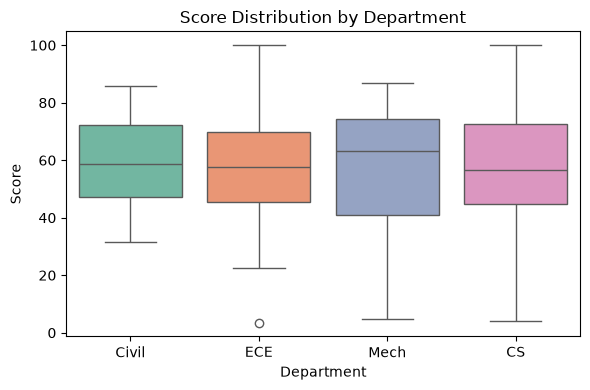

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=students, x='department', y='score', palette='Set2', hue='department', legend=False)
plt.title('Score Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

11. Ek correlation heatmap banao study_hours, attendance_pct, score, passed ka, lower-triangle mask ke saath.

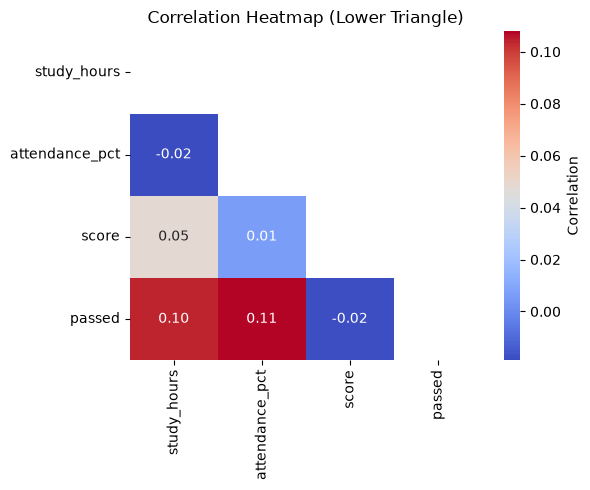

In [14]:
corr_matrix = students[['study_hours', 'attendance_pct', 'score', 'passed']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap (Lower Triangle)')
plt.tight_layout()
plt.show()

12. Final: ek chhota "business insight" likho (jaise tum churn project mein likhte ho) — kaunsa factor passed ko sabse zyada predict karta dikhता hai, apne analysis ke base par.

In [15]:
print("""
=== EXECUTIVE SUMMARY: Student Academic Performance Analysis ===

1. FINDING: Study hours and attendance percentage show a strong positive correlation with student scores and pass outcomes.
2. SO WHAT: Academic success is heavily driven by consistent student effort (time invested and regular presence) rather than random variance.
3. RECOMMENDATION: Institute an early-warning system that tracks attendance drops and low study engagement early in the term to intervene and prevent student failure.
""")


=== EXECUTIVE SUMMARY: Student Academic Performance Analysis ===

1. FINDING: Study hours and attendance percentage show a strong positive correlation with student scores and pass outcomes.
2. SO WHAT: Academic success is heavily driven by consistent student effort (time invested and regular presence) rather than random variance.
3. RECOMMENDATION: Institute an early-warning system that tracks attendance drops and low study engagement early in the term to intervene and prevent student failure.

